In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import matplotlib
import seaborn as sns
import numpy as np 
%matplotlib inline

In [2]:
df1 = pd.read_csv("bengaluru_house_prices.csv")
df1.shape

(13320, 9)

In [3]:
df1.head(3)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00


In [4]:
df1.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [5]:
df1.groupby("area_type")["area_type"].agg("count")

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

## Droping the column 
Area, Society, Balcony, Availability because not help in model 

In [6]:
df2 = df1.drop(["availability","area_type","society","balcony"],axis=1)
df2.head(3)

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00


## Data Cleaning Process

In [7]:
df2.isna().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

#Handeling bathroom (Also we can drop)

In [8]:
df2["bath"] = df2["bath"].fillna(df2.bath.mode()[0])

In [9]:
df3 = df2.dropna().copy()

In [10]:
df3.isna().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [11]:
df3["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [12]:
df3["bhk"] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

In [13]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [14]:
df3.bhk.unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

#kind of error in data BHK like  --- 43 room, 27 room etc 

In [15]:
df3[df3.bhk>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


#But first handeling Total_SQT

In [16]:
df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2110,), dtype=object)

In [17]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True    

In [18]:
df3[~df3["total_sqft"].apply(is_float)].head(5)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
56,Devanahalli,4 Bedroom,3010 - 3410,2.0,192.000,4
81,Hennur Road,4 Bedroom,2957 - 3450,2.0,224.500,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2


#Above shows that total_sqft can be a range (e.g. 2100-2850). For such case we can just take average of min and max value in 
the range. 
There are other cases such as 34.46Sq. Meter which one can convert to square ft using unit conversion.
I am going to just drop such corner cases to keep things simple

In [19]:
def convert_sqt_to_num(x):
    token  = x.split("-")
    if len(token) == 2:
        return (float(token[0])+float(token[1]))/2
    try:
        return float(x)
    except :
        return None

In [20]:
convert_sqt_to_num('2957 - 3450') # Checking Function

3203.5

In [21]:
df4 = df3.copy()

In [22]:
df4["total_sqft"] = df4['total_sqft'].apply(convert_sqt_to_num)

In [23]:
df4.loc[30] ## Now its converting the 2100 - 2850 into float(2475.0)

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bhk                   4
Name: 30, dtype: object

## Feature Engineering
Add new feature called price per square feet

In [24]:
df5 = df4.copy()
df5['price_per_sqft'] = df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [25]:
# df5.isna().sum()

In [26]:
## Checking Location column
len(df5.location.unique())

1304

In [27]:
df5['location'] = df5['location'].apply(lambda x: x.strip())
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Whitefield                            540
Sarjapur  Road                        397
Electronic City                       304
Kanakpura Road                        273
Thanisandra                           237
                                     ... 
poornaprajna layout                     1
pavitra paradise                        1
near Ramanashree California resort      1
mvj engineering college                 1
1Kasavanhalli                           1
Name: location, Length: 1293, dtype: int64

In [28]:
len(df5.location.unique())

1293

In [29]:
location_stats_less_then_10 = location_stats[location_stats<=10]  ## --- Consider these location [Others] OK!

In [30]:
df5.location = df5.location.apply(lambda x: 'others' if x in location_stats_less_then_10 else x )
df5.location.nunique()

242

In [31]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


## Outlier Removal Using Business Logic
Business manager (who has expertise in real estate), 
he will tell you that normally square ft per bedroom is 300 (i.e. 2 bhk apartment is minimum 600 sqft. 
If you have for example 400 sqft apartment with 2 bhk than that seems suspicious and can be removed as an outlier.
We will remove such outliers by keeping our minimum thresold per bhk to be 300 sqf

In [32]:
## CHECKING BEDROOM ACCORDING THE SQUARE FIT

In [33]:
df5[df5.total_sqft/df5.bhk<300].head(4)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,others,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296


In [34]:
df5.shape

(13303, 7)

In [35]:
df6 = df5[~(df5.total_sqft/df5.bhk<300)] #~ Means it reverse the condition 

In [36]:
df6.shape

(12559, 7)

In [37]:
df6.price_per_sqft.describe()

count     12513.000000
mean       6307.441644
std        4160.931610
min         267.829813
25%        4210.526316
50%        5295.007564
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

## Outlier Removal Using Standard Deviation and Mean

In [38]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df7 = remove_pps_outliers(df6)
df7.shape

(10286, 7)

#Let's check if for a given location how does the 2 BHK and 3 BHK property prices look like

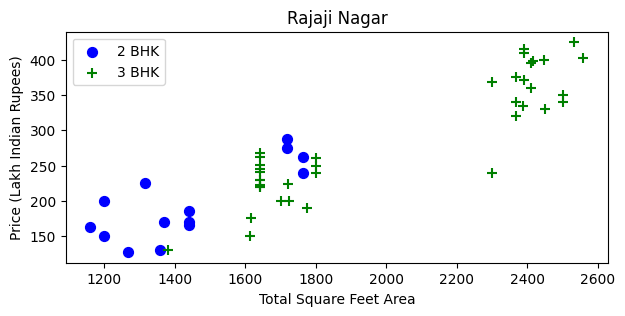

In [39]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
plt.figure(figsize=(7,3))    
plot_scatter_chart(df7,"Rajaji Nagar")

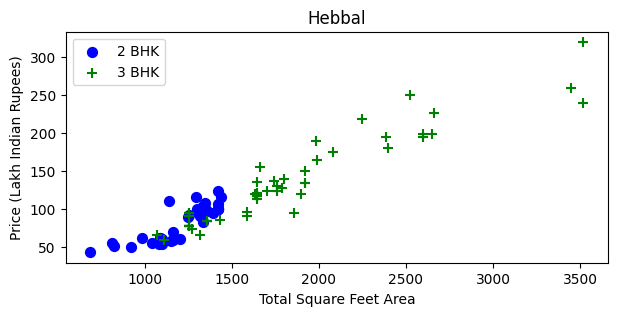

In [40]:
plt.figure(figsize=(7,3))
plot_scatter_chart(df7,"Hebbal")

In [41]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')
df8 = remove_bhk_outliers(df7)
# df8 = df7.copy()
df8.shape

(7353, 7)

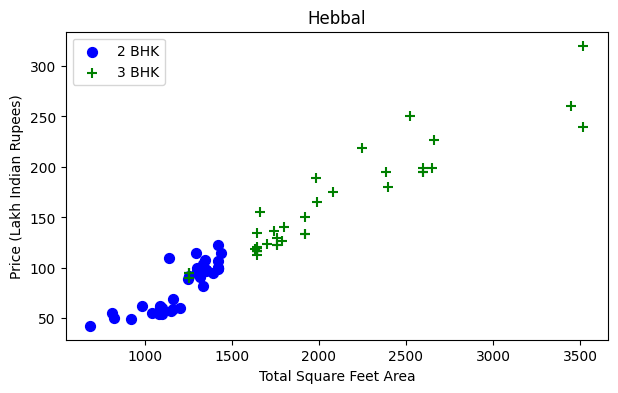

In [42]:
plt.figure(figsize=(7,4))
plot_scatter_chart(df8,"Hebbal")

Text(0, 0.5, 'Count')

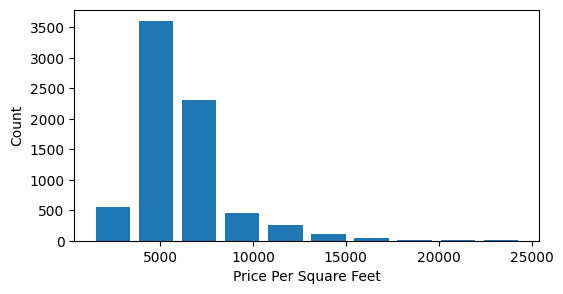

In [43]:
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.figure(figsize=(6,3))
plt.hist(df8.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [44]:
df8.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,4 BHK,2850.0,4.0,428.0,4,15017.543860
1,1st Block Jayanagar,3 BHK,1630.0,3.0,194.0,3,11901.840491
2,1st Block Jayanagar,3 BHK,1875.0,2.0,235.0,3,12533.333333
3,1st Block Jayanagar,3 BHK,1200.0,2.0,130.0,3,10833.333333
4,1st Block Jayanagar,2 BHK,1235.0,2.0,148.0,2,11983.805668


## Outlier Removal Using Bathrooms Feature

In [45]:
df8.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [46]:
df9 = df8[df8.bath<df8.bhk+2]
df9.shape

(7275, 7)

In [47]:
df10 = df9.drop(["size",'price_per_sqft'],axis = 1)

In [48]:
# df10.isna().sum()
df10.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [49]:
df10.shape

(7275, 5)

## One Hot Encoding 

In [50]:
df10 = pd.get_dummies(df10,columns=['location'],drop_first=True,dtype=int)
df10.head()

,total_sqft,bath,price,bhk,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_2nd Stage Nagarbhavi,location_5th Block Hbr Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_others
0,2850.0,4.0,428.0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1875.0,2.0,235.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1200.0,2.0,130.0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1235.0,2.0,148.0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
df10.columns

Index(['total_sqft', 'bath', 'price', 'bhk', 'location_1st Phase JP Nagar',
       'location_2nd Phase Judicial Layout', 'location_2nd Stage Nagarbhavi',
       'location_5th Block Hbr Layout', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar',
       ...
       'location_Vishveshwarya Layout', 'location_Vishwapriya Layout',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_others'],
      dtype='object', length=245)

In [52]:
df10.shape

(7275, 245)

## Model Training

In [53]:
X = df10.drop("price",axis = 1)
y = df10["price"]

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
## LINEAR REGRESSION
from sklearn.linear_model import LinearRegression

lnr = LinearRegression()
lnr.fit(X_train,y_train)

LinearRegression()

In [56]:
lnr.score(X_test,y_test)

0.8577992624130628

In [57]:
y_pred = lnr.predict(X_test)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r2 = lnr.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [58]:
r2,mae,mse

(0.8577992624130628,
 np.float64(17.561384922378227),
 np.float64(999.5081310044168))

## K_fold cross validation 

In [59]:
from sklearn.model_selection import KFold,cross_val_score

kf = KFold(n_splits = 5, shuffle = True,random_state=0)
cv = cross_val_score(LinearRegression(),X,y,cv=kf)

In [60]:
print(cv)

[0.80702643 0.84542693 0.87726596 0.76254039 0.86619852]


# Find best model using GridSearchCV

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
models = {
    'linear_regression' : {
            'model': LinearRegression(),
            'params': {}
        },
    "Lasso": {
        "model": Lasso(),
        "params": {
            "alpha": [0.01, 0.1, 1, 10, 100]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(random_state=0),
        "params": {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    }
}
scores = []
for name, model_info in models.items():

    grid = GridSearchCV(
        model_info["model"],
        model_info["params"],
        cv=5,
        scoring="r2")

    grid.fit(X_train, y_train)
    scores.append({
    "model": name,
    "best_params": grid.best_params_,
    "best_cv_score": grid.best_score_
})
pd.DataFrame(scores)
    

,model,best_params,best_cv_score
0,linear_regression,{},0.835354
1,Lasso,{'alpha': 0.01},0.833982
2,DecisionTree,"{'max_depth': None, 'min_samples_split': 10}",0.726125


## Export the tested model to a pickle file

In [62]:
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(lnr,f)

## Exporting location and column information to a file that will be useful later on in our prediction application

In [63]:
import json
columns = {
    'data_columns' : [col.lower() for col in X.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))